# 02 · Rule baseline and machine-learning models

**Goal:** find the model that best ranks transactions by fraud risk, and measure how much it improves on the rules a fraud team would run today.

**Protocol. This is what keeps the results honest:**
| Split | Used for |
|---|---|
| Train (earliest 60%) | fitting models, rule cut-offs, encoders, scalers and resampling |
| Validation (next 20%) | choosing hyper-parameters, early stopping, the imbalance treatment and the model |
| Test (latest 20%) | **one** final evaluation at the end of this notebook |

**Metrics.** PR-AUC (average precision) is primary. With 0.5% fraud, a model that flags nothing is 99.5% "accurate", and ROC-AUC rewards correctly ranking the huge pool of easy negatives. PR-AUC measures what an alert queue feels like: how clean the alerts are (precision) at each level of fraud caught (recall). ROC-AUC is reported only as a secondary metric.

In [1]:
import sys, pathlib, json, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display
from sklearn.metrics import precision_recall_curve, confusion_matrix

from src import config, data, features, metrics, models, rules, plotting
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 180, "display.max_columns", 30, "display.float_format", "{:,.4f}".format)
np.random.seed(config.SEED)

df = features.add_derived(data.load_features())
df = df.merge(pd.read_parquet(config.DATA_PROCESSED / "splits.parquet"), on="trans_num")
tr, va, te = (df[df.split == s].reset_index(drop=True) for s in ["train", "validation", "test"])
days = {"validation": metrics.n_days(va.ts), "test": metrics.n_days(te.ts)}
CATS = sorted(tr.category.unique())          # category levels fixed from train
print({k: len(v) for k, v in zip(["train", "validation", "test"], [tr, va, te])}, days)

{'train': 1110690, 'validation': 371005, 'test': 370699} {'validation': 140, 'test': 129}


## 1. Rule-based baseline

There are four rules a fraud operations team would realistically run. Each maps to a pattern seen in the EDA:

| Rule | Fraud pattern it targets |
|---|---|
| R1 High amount at night | Fraud concentrates at 22:00–04:00 and at $250+ |
| R2 24h spend spike | Velocity: several large charges in quick succession on a compromised card |
| R3 Far above the customer's norm | Amount far above what this customer usually spends |
| R4 High-risk category, large amount | Online shopping, misc-online and grocery POS carry most fraud dollars |

Cut-offs are chosen **on train only**, by grid search over round numbers an analyst could say out loud, maximising each rule's F1. The baseline alerts when **any** rule fires.

In [2]:
RULES = rules.fit_rules(tr)
rule_perf = pd.concat([rules.rule_table(RULES, tr, "train"), rules.rule_table(RULES, va, "validation")])
rule_perf.to_csv(config.REPORTS / "rules_performance.csv", index=False)
rule_perf

,rule,definition,split,alerts,precision,recall,f1
0,R1 high amount at night,Amount >= $250 between 22:00 and 04:00,train,10353,0.3913,0.6344,0.4840
1,R2 24h spend spike,Card spend in last 24h (incl. this txn) >= $2500,train,6641,0.4264,0.4435,0.4348
2,R3 far above customer norm,Amount >= 8x the customer's historical average...,train,9679,0.2498,0.3786,0.3010
3,"R4 high-risk category, large amount","Category in ('shopping_net', 'misc_net', 'groc...",train,3723,0.5415,0.3157,0.3989
0,R1 high amount at night,Amount >= $250 between 22:00 and 04:00,validation,3240,0.3701,0.6287,0.4659
1,R2 24h spend spike,Card spend in last 24h (incl. this txn) >= $2500,validation,2111,0.3908,0.4326,0.4107
2,R3 far above customer norm,Amount >= 8x the customer's historical average...,validation,3250,0.2440,0.4158,0.3075
3,"R4 high-risk category, large amount","Category in ('shopping_net', 'misc_net', 'groc...",validation,1146,0.4921,0.2958,0.3695


In [3]:
score_rules_va = rules.rule_score(RULES, va)
rules_va = metrics.at_threshold(va.is_fraud, score_rules_va, va.amt, 1, days["validation"])
pd.Series(rules_va).to_frame("Rules baseline (any rule fires), validation")

,"Rules baseline (any rule fires), validation"
threshold,1.0000
alerts,"6,497.0000"
alerts_per_day,46.4071
TP,"1,520.0000"
FP,"4,977.0000"
FN,387.0000
TN,"364,121.0000"
precision,0.2340
recall,0.7971
f1,0.3617


In [4]:
takeaway(f"On validation, the four rules together catch {rules_va['recall']:.0%} of frauds "
         f"({rules_va['dollar_recall']:.0%} of fraud dollars), but only {rules_va['precision']:.0%} of alerts are fraud: "
         f"{rules_va['false_alerts_per_day']:.0f} false alerts per day. That's the bar the models must beat.")

**Takeaway:** On validation, the four rules together catch 80% of frauds (97% of fraud dollars), but only 23% of alerts are fraud: 36 false alerts per day. That's the bar the models must beat.

## 2. Logistic regression (class-weighted)

`class_weight="balanced"` up-weights each fraud so the loss isn't dominated by legitimate transactions. The inputs are imputed (with missing-value flags), log-compressed and standardised, and every transform is fitted on train only (`src/features.linear_preprocessor`). The regularisation strength `C` is tuned on validation PR-AUC.

In [5]:
lr_grid = []
for C in [0.001, 0.01, 0.1, 1.0]:
    m = models.fit_logreg(tr, C)
    lr_grid.append({"C": C, "val_pr_auc": metrics.pr_auc(va.is_fraud, m.predict_proba(va)[:, 1]), "model": m})
lr_grid_df = pd.DataFrame(lr_grid).drop(columns="model")
best_lr = max(lr_grid, key=lambda r: r["val_pr_auc"])
LR = best_lr["model"]
print(f"Chosen C = {best_lr['C']}")
lr_grid_df.to_csv(config.REPORTS / "tuning_logreg.csv", index=False)
lr_grid_df

Chosen C = 0.001


,C,val_pr_auc
0,0.0010,0.6280
1,0.0100,0.6178
2,0.1000,0.6162
3,1.0000,0.6158


## 3. Random forest

This uses balanced class weights per tree (`balanced_subsample`), and each tree sees a 25% bootstrap sample so that training on 1.1M rows stays tractable. `min_samples_leaf` is tuned on validation. Larger leaves give smoother probability estimates and less memorisation of individual fraud bursts.

In [6]:
Xo_tr, Xo_va, Xo_te = (features.onehot_frame(d, CATS) for d in (tr, va, te))
rf_grid = []
for leaf in [5, 25]:
    t0 = time.time()
    m = models.fit_random_forest(Xo_tr, tr.is_fraud, min_samples_leaf=leaf)
    rf_grid.append({"min_samples_leaf": leaf, "val_pr_auc": metrics.pr_auc(va.is_fraud, m.predict_proba(Xo_va)[:, 1]),
                    "fit_seconds": round(time.time() - t0), "model": m})
rf_grid_df = pd.DataFrame(rf_grid).drop(columns="model")
best_rf = max(rf_grid, key=lambda r: r["val_pr_auc"])
RF = best_rf["model"]
print(f"Chosen min_samples_leaf = {best_rf['min_samples_leaf']}")
rf_grid_df.to_csv(config.REPORTS / "tuning_random_forest.csv", index=False)
rf_grid_df

Chosen min_samples_leaf = 5


,min_samples_leaf,val_pr_auc,fit_seconds
0,5,0.9386,70
1,25,0.9148,70


## 4. LightGBM: which imbalance treatment?

This keeps the hyper-parameters fixed and changes **only** how class imbalance is handled. All resampling touches the **training split only**. Validation and test keep their real fraud rate, because that is what production looks like.

| Treatment | What it does | Risk |
|---|---|---|
| No weighting | Plain log-loss | Minority signal can be swamped |
| Class weights | Each fraud is weighted by legit/fraud (~173x) | Inflates scores, so probabilities are no longer calibrated |
| Random undersampling 1:10 | Drops ~94% of legitimate training rows | Throws away information about normal behaviour |
| SMOTE 1:10 | Creates synthetic frauds by interpolating between fraud neighbours | Synthetic points can be unrealistic, e.g. fractional one-hot categories or blends of two different cards' behaviour |

**Decision rule (set before looking at results).** Take the treatment with the best validation PR-AUC. If a simpler treatment (order: none, then weights, then undersampling, then SMOTE) is within noise, meaning the 95% card-level bootstrap interval of the difference includes zero, prefer the simpler one. The bootstrap resamples whole **cards**, because frauds come in bursts on the same card and rows aren't independent.

In [7]:
imb_table, imb_models = models.imbalance_experiment(tr, va, CATS)
Xt_tr, Xt_va, Xt_te = (features.tree_frame(d, CATS) for d in (tr, va, te))
imb_scores = {k: m.predict_proba(Xo_va if k.startswith("SMOTE") else Xt_va)[:, 1] for k, m in imb_models.items()}

BOOT_VA = metrics.card_bootstrap_indices(va.cc_num, n_boot=200, seed=config.SEED)
imb_boot = metrics.bootstrap_matrix(va.is_fraud, imb_scores, BOOT_VA)
imb_summary = metrics.summarise_bootstrap(va.is_fraud, imb_scores, imb_boot).rename(columns={"model": "treatment"})
imb_table = imb_table.merge(imb_summary[["treatment", "ci_low", "ci_high"]], on="treatment")
imb_table

/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,treatment,val_pr_auc,best_iteration,fit_seconds,ci_low,ci_high
0,No weighting,0.9706,788,96.0000,0.9635,0.9771
1,Class weights (scale_pos_weight),0.9685,1720,201.4000,0.9601,0.9754
2,Random undersampling 1:10,0.9676,555,35.7000,0.9590,0.9749
3,SMOTE to 1:10,0.9752,1005,133.4000,0.9682,0.9811


In [8]:
order = ["No weighting", "Class weights (scale_pos_weight)", "Random undersampling 1:10", "SMOTE to 1:10"]
best_t = imb_table.sort_values("val_pr_auc", ascending=False).treatment.iloc[0]
rows = []
for t in order:
    lo, hi = metrics.paired_diff(imb_boot, best_t, t) if t != best_t else (0.0, 0.0)
    rows.append({"treatment": t, "diff_vs_best": imb_table.set_index("treatment").val_pr_auc[best_t] - imb_table.set_index("treatment").val_pr_auc[t],
                 "diff_ci_low": lo, "diff_ci_high": hi, "within_noise": lo <= 0 <= hi})
diff_table = pd.DataFrame(rows)
chosen_treatment = next(r["treatment"] for r in rows if r["within_noise"])   # simplest treatment within noise of the best
imb_table.merge(diff_table, on="treatment").to_csv(config.REPORTS / "imbalance_comparison.csv", index=False)
print(f"Best on validation: {best_t}.  Chosen by the decision rule: {chosen_treatment}")
diff_table

Best on validation: SMOTE to 1:10.  Chosen by the decision rule: SMOTE to 1:10


,treatment,diff_vs_best,diff_ci_low,diff_ci_high,within_noise
0,No weighting,0.0046,0.0031,0.0063,False
1,Class weights (scale_pos_weight),0.0066,0.0042,0.0089,False
2,Random undersampling 1:10,0.0076,0.0053,0.0097,False
3,SMOTE to 1:10,0.0000,0.0000,0.0000,True


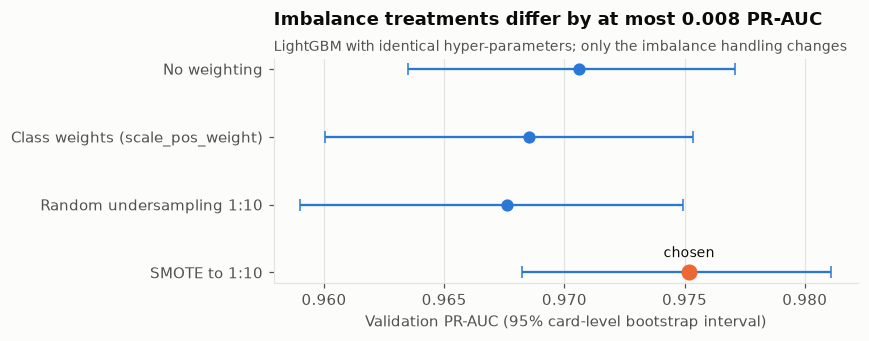

**Takeaway:** The spread between the best and worst treatment is 0.008 PR-AUC. With strong behavioural features, how the imbalance is handled matters far less than what the features capture. The per-model intervals overlap, but the *paired* bootstrap (same resampled cards for every treatment) shows whether the gap is consistent. That's the fair test, because hard cards are hard for every model. Undersampling trains several times faster for a small loss, a reasonable trade-off when frequent retraining matters.

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.2))
t = imb_table.set_index("treatment").loc[order[::-1]]
ax.errorbar(t.val_pr_auc, t.index, xerr=[t.val_pr_auc - t.ci_low, t.ci_high - t.val_pr_auc],
            fmt="o", color=plotting.BLUE, ms=7, capsize=4, lw=1.5)
ax.scatter([t.loc[chosen_treatment, "val_pr_auc"]], [chosen_treatment], s=90, color=plotting.ORANGE, zorder=3)
ax.annotate("chosen", (t.loc[chosen_treatment, "val_pr_auc"], chosen_treatment), xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=9, color=plotting.TEXT)
ax.set_xlabel("Validation PR-AUC (95% card-level bootstrap interval)")
ax.grid(axis="y", visible=False)
plotting.title(ax, f"Imbalance treatments differ by at most {imb_table.val_pr_auc.max() - imb_table.val_pr_auc.min():.3f} PR-AUC",
               "LightGBM with identical hyper-parameters; only the imbalance handling changes")
plotting.save(fig, "imbalance_treatment_comparison"); plt.show()
spread = imb_table.val_pr_auc.max() - imb_table.val_pr_auc.min()
takeaway(f"The spread between the best and worst treatment is {spread:.3f} PR-AUC. With strong behavioural features, "
         "how the imbalance is handled matters far less than what the features capture. The per-model intervals overlap, but the *paired* "
         "bootstrap (same resampled cards for every treatment) shows whether the gap is consistent. That's the fair test, because hard cards are hard for every model. "
         "Undersampling trains several times faster for a small loss, a reasonable trade-off when frequent retraining matters.")

### LightGBM hyper-parameters

With the imbalance treatment fixed, we tune tree complexity (`num_leaves`) on validation. Early stopping on validation PR-AUC picks the number of trees.

In [10]:
def lgb_fit_variant(treatment, **kw):
    y_tr, y_va = tr.is_fraud, va.is_fraud
    if treatment == "No weighting":
        return models.fit_lgbm(Xt_tr, y_tr, Xt_va, y_va, **kw), "tree"
    if treatment.startswith("Class weights"):
        return models.fit_lgbm(Xt_tr, y_tr, Xt_va, y_va, scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(), **kw), "tree"
    if treatment.startswith("Random under"):
        return models.fit_lgbm(*models.resample(Xt_tr, y_tr, "undersample"), Xt_va, y_va, **kw), "tree"
    return models.fit_lgbm(*models.resample(Xo_tr, y_tr, "smote"), Xo_va, y_va, **kw), "onehot"

frames = {"tree": (Xt_va, Xt_te), "onehot": (Xo_va, Xo_te)}
lgb_grid = [{"num_leaves": 31, "model": imb_models[chosen_treatment],
             "frame": "onehot" if chosen_treatment.startswith("SMOTE") else "tree"}]
for leaves in [7, 15, 63]:
    m, fr = lgb_fit_variant(chosen_treatment, num_leaves=leaves)
    lgb_grid.append({"num_leaves": leaves, "model": m, "frame": fr})
for g in lgb_grid:
    g["val_pr_auc"] = metrics.pr_auc(va.is_fraud, g["model"].predict_proba(frames[g["frame"]][0])[:, 1])
    g["n_trees"] = g["model"].best_iteration_
lgb_grid_df = pd.DataFrame(lgb_grid)[["num_leaves", "n_trees", "val_pr_auc"]].sort_values("num_leaves")
best_lgb = max(lgb_grid, key=lambda r: r["val_pr_auc"])
LGB, LGB_FRAME = best_lgb["model"], best_lgb["frame"]
print(f"Chosen num_leaves = {best_lgb['num_leaves']} ({best_lgb['n_trees']} trees)")
lgb_grid_df.to_csv(config.REPORTS / "tuning_lightgbm.csv", index=False)
lgb_grid_df

/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


/home/claude/venv/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Chosen num_leaves = 15 (1504 trees)


,num_leaves,n_trees,val_pr_auc
1,7,2233,0.9750
2,15,1504,0.9757
0,31,1005,0.9752
3,63,745,0.9747


## 5. Model comparison on validation

Each model is compared at its own **F1-maximising threshold, chosen on validation**. That gives a neutral operating point for comparing models. The *business* thresholds (cost-minimising, capacity and recall target) are set in notebook 03.

We also add an **undersampled LightGBM** to the comparison. It trains in a fraction of the time, which makes it a realistic "cheap to retrain" alternative.

In [11]:
under_model = imb_models["Random undersampling 1:10"]
MODELS = {
    "Rules baseline": (lambda d, X_t, X_o: rules.rule_score(RULES, d)),
    "Logistic regression": (lambda d, X_t, X_o: LR.predict_proba(d)[:, 1]),
    "Random forest": (lambda d, X_t, X_o: RF.predict_proba(X_o)[:, 1]),
    "LightGBM": (lambda d, X_t, X_o: LGB.predict_proba(X_o if LGB_FRAME == "onehot" else X_t)[:, 1]),
    "LightGBM (undersampled)": (lambda d, X_t, X_o: under_model.predict_proba(X_t)[:, 1]),
}
val_scores = {name: f(va, Xt_va, Xo_va) for name, f in MODELS.items()}

thresholds = {}
rows = []
val_boot = metrics.bootstrap_matrix(va.is_fraud, val_scores, BOOT_VA)
val_ci = metrics.summarise_bootstrap(va.is_fraud, val_scores, val_boot).set_index("model")
for name, s in val_scores.items():
    thr = 1.0 if name == "Rules baseline" else metrics.best_f1_threshold(va.is_fraud, s)
    thresholds[name] = thr
    r = metrics.at_threshold(va.is_fraud, s, va.amt, thr, days["validation"])
    rows.append({"model": name, "PR-AUC": val_ci.loc[name, "pr_auc"],
                 "PR-AUC 95% CI": f"{val_ci.loc[name, 'ci_low']:.3f}-{val_ci.loc[name, 'ci_high']:.3f}",
                 "ROC-AUC": metrics.roc_auc(va.is_fraud, s), **r})
val_table = pd.DataFrame(rows).set_index("model")
cols = ["PR-AUC", "PR-AUC 95% CI", "ROC-AUC", "threshold", "precision", "recall", "f1", "TP", "FP", "FN",
        "alerts_per_day", "false_alerts_per_day", "fraud_caught_usd", "dollar_recall"]
val_table[cols].to_csv(config.REPORTS / "model_comparison_validation.csv")
val_table[cols]

,PR-AUC,PR-AUC 95% CI,ROC-AUC,threshold,precision,recall,f1,TP,FP,FN,alerts_per_day,false_alerts_per_day,fraud_caught_usd,dollar_recall
model,,,,,,,,,,,,,,
Rules baseline,0.4248,0.391-0.462,0.8944,1.0000,0.2340,0.7971,0.3617,1520,4977,387,46.4071,35.5500,"963,156.6200",0.9719
Logistic regression,0.6280,0.591-0.665,0.9779,0.9632,0.6959,0.5784,0.6317,1103,482,804,11.3214,3.4429,"775,547.3800",0.7826
Random forest,0.9386,0.928-0.950,0.9965,0.4366,0.9145,0.8584,0.8856,1637,153,270,12.7857,1.0929,"919,148.8300",0.9275
LightGBM,0.9757,0.969-0.981,0.9995,0.2845,0.9603,0.9130,0.9360,1741,72,166,12.9500,0.5143,"942,844.6000",0.9514
LightGBM (undersampled),0.9676,0.959-0.975,0.9994,0.9068,0.9415,0.9035,0.9221,1723,107,184,13.0714,0.7643,"938,978.0600",0.9475


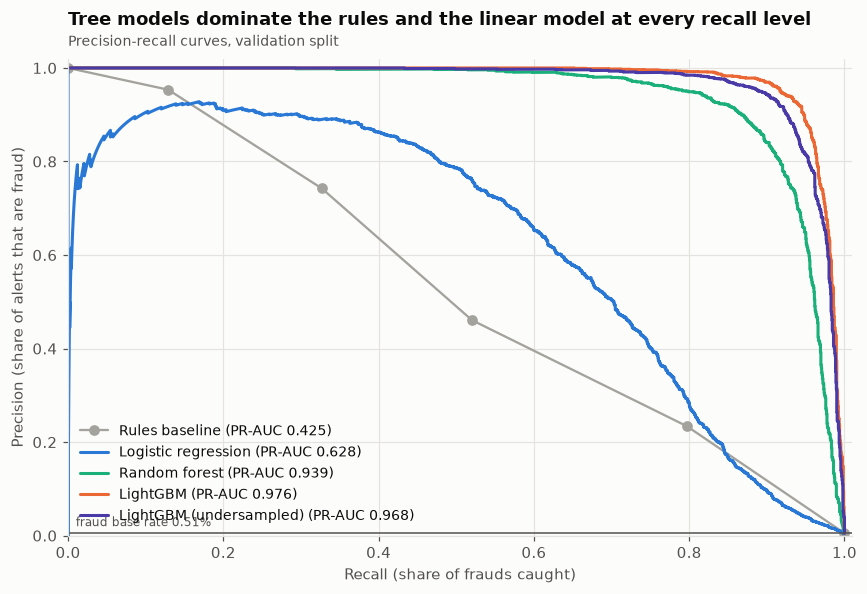

In [12]:
def pr_plot(ax, y, scores, title_text, subtitle):
    for name, s in scores.items():
        p, r, _ = precision_recall_curve(y, s)
        style = dict(color=plotting.MODEL_COLORS[name], lw=2)
        if name == "Rules baseline":
            style.update(marker="o", ms=6, lw=1.5, ls="-")
        ax.plot(r, p, label=f"{name} (PR-AUC {metrics.pr_auc(y, s):.3f})", **style)
    ax.axhline(np.mean(y), color=plotting.TEXT_2, lw=1)
    ax.text(0.01, np.mean(y) + 0.015, f"fraud base rate {np.mean(y):.2%}", color=plotting.TEXT_2, fontsize=8)
    ax.set_xlabel("Recall (share of frauds caught)"); ax.set_ylabel("Precision (share of alerts that are fraud)")
    ax.set_xlim(0, 1.01); ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left", fontsize=9)
    plotting.title(ax, title_text, subtitle)

fig, ax = plt.subplots(figsize=(8, 5.5))
pr_plot(ax, va.is_fraud, val_scores, "Tree models dominate the rules and the linear model at every recall level",
        "Precision-recall curves, validation split")
plotting.save(fig, "pr_curves_validation"); plt.show()

In [13]:
v = val_table
best_name = v.drop(index="Rules baseline")["PR-AUC"].idxmax()
takeaway(f"On validation, {best_name} reaches PR-AUC {v.loc[best_name, 'PR-AUC']:.3f} vs {v.loc['Rules baseline', 'PR-AUC']:.3f} for the rules. "
         f"At its F1 threshold it catches {v.loc[best_name, 'recall']:.0%} of frauds with {v.loc[best_name, 'precision']:.0%} precision, "
         f"generating {v.loc[best_name, 'false_alerts_per_day']:.1f} false alerts/day vs {v.loc['Rules baseline', 'false_alerts_per_day']:.1f} for the rules. "
         f"Logistic regression ({v.loc['Logistic regression', 'PR-AUC']:.3f}) most likely lags because the fraud signal is an interaction "
         "(large amount AND night AND unusual for this customer), which a linear model can't represent without hand-built interaction terms.")

**Takeaway:** On validation, LightGBM reaches PR-AUC 0.976 vs 0.425 for the rules. At its F1 threshold it catches 91% of frauds with 96% precision, generating 0.5 false alerts/day vs 35.5 for the rules. Logistic regression (0.628) most likely lags because the fraud signal is an interaction (large amount AND night AND unusual for this customer), which a linear model can't represent without hand-built interaction terms.

**Model selection.** LightGBM (class treatment and `num_leaves` chosen above) is carried forward as the production candidate. The reasons are the highest validation PR-AUC, fast scoring, native handling of missing values (the "no history yet" case), and exact, fast SHAP explanations for tree models (notebook 04). The rules baseline stays in every comparison as the "current process".

## 6. Final evaluation on the test set: used once

Every choice so far (rule cut-offs, `C`, `min_samples_leaf`, imbalance treatment, `num_leaves`, number of trees and thresholds) was made without the test set. We now score test once and apply the validation-chosen thresholds unchanged.

In [14]:
test_scores = {name: f(te, Xt_te, Xo_te) for name, f in MODELS.items()}
BOOT_TE = metrics.card_bootstrap_indices(te.cc_num, n_boot=200, seed=config.SEED)
te_boot = metrics.bootstrap_matrix(te.is_fraud, test_scores, BOOT_TE)
te_ci = metrics.summarise_bootstrap(te.is_fraud, test_scores, te_boot).set_index("model")
rows = []
for name, s in test_scores.items():
    r = metrics.at_threshold(te.is_fraud, s, te.amt, thresholds[name], days["test"])
    rows.append({"model": name, "PR-AUC": te_ci.loc[name, "pr_auc"],
                 "PR-AUC 95% CI": f"{te_ci.loc[name, 'ci_low']:.3f}-{te_ci.loc[name, 'ci_high']:.3f}",
                 "ROC-AUC": metrics.roc_auc(te.is_fraud, s), **r})
test_table = pd.DataFrame(rows).set_index("model")
test_table[cols].to_csv(config.REPORTS / "model_comparison_test.csv")
test_table[cols]

,PR-AUC,PR-AUC 95% CI,ROC-AUC,threshold,precision,recall,f1,TP,FP,FN,alerts_per_day,false_alerts_per_day,fraud_caught_usd,dollar_recall
model,,,,,,,,,,,,,,
Rules baseline,0.4133,0.369-0.454,0.9032,1.0000,0.1710,0.8144,0.2826,1106,5362,252,50.1395,41.5659,"717,171.2700",0.9717
Logistic regression,0.6370,0.589-0.686,0.9811,0.9632,0.6859,0.5950,0.6372,808,370,550,9.1318,2.8682,"591,634.8300",0.8016
Random forest,0.9257,0.906-0.941,0.9954,0.4366,0.9208,0.8130,0.8635,1104,95,254,9.2946,0.7364,"664,926.4700",0.9009
LightGBM,0.9697,0.960-0.978,0.9994,0.2845,0.9547,0.8991,0.9261,1221,58,137,9.9147,0.4496,"689,462.1600",0.9342
LightGBM (undersampled),0.9655,0.954-0.974,0.9993,0.9068,0.9384,0.8866,0.9118,1204,79,154,9.9457,0.6124,"692,334.2300",0.9381


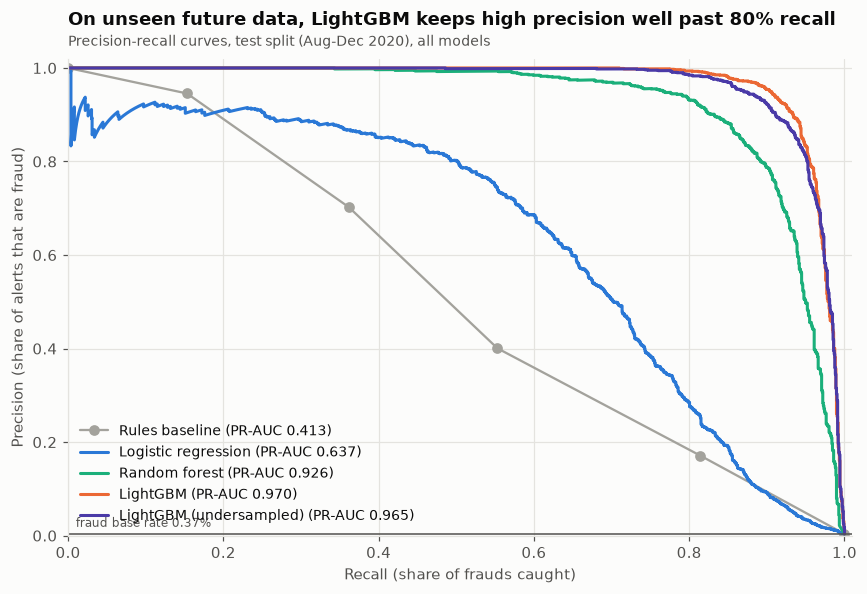

In [15]:
fig, ax = plt.subplots(figsize=(8, 5.5))
pr_plot(ax, te.is_fraud, test_scores, "On unseen future data, LightGBM keeps high precision well past 80% recall",
        "Precision-recall curves, test split (Aug-Dec 2020), all models")
plotting.save(fig, "pr_curves_test"); plt.show()

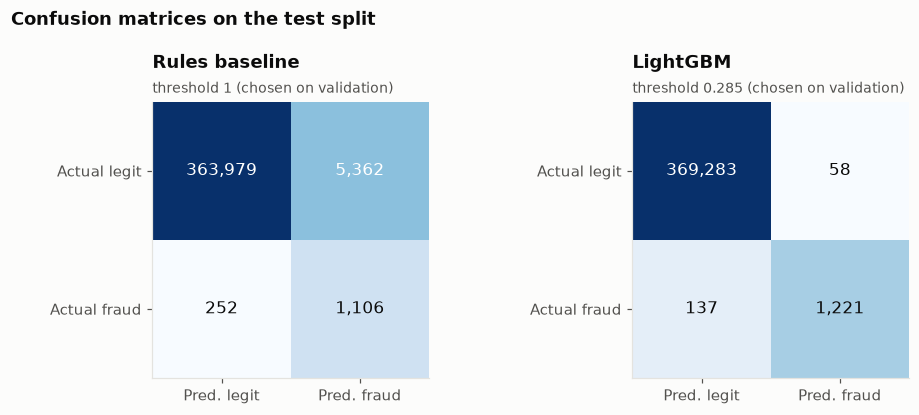

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, name in zip(axes, ["Rules baseline", "LightGBM"]):
    s = test_scores[name]
    cm = confusion_matrix(te.is_fraud, s >= thresholds[name])
    ax.imshow(np.log1p(cm), cmap="Blues")
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f"{val:,}", ha="center", va="center", color="white" if np.log1p(val) > np.log1p(cm).max() * 0.6 else plotting.TEXT, fontsize=11)
    ax.set_xticks([0, 1], ["Pred. legit", "Pred. fraud"]); ax.set_yticks([0, 1], ["Actual legit", "Actual fraud"])
    ax.grid(False)
    plotting.title(ax, name, f"threshold {thresholds[name]:.3g} (chosen on validation)")
fig.suptitle("Confusion matrices on the test split", x=0.02, ha="left", fontweight="bold")
plotting.save(fig, "confusion_matrices_test"); plt.show()

In [17]:
t = test_table
takeaway(f"On test, LightGBM holds PR-AUC {t.loc['LightGBM', 'PR-AUC']:.3f} (validation: {val_table.loc['LightGBM', 'PR-AUC']:.3f}). "
         f"With the validation threshold it catches {t.loc['LightGBM', 'TP']:,} of {t.loc['LightGBM', 'TP'] + t.loc['LightGBM', 'FN']:,} frauds "
         f"(\\${t.loc['LightGBM', 'fraud_caught_usd']:,.0f}) with {t.loc['LightGBM', 'FP']:,} false alerts "
         f"({t.loc['LightGBM', 'false_alerts_per_day']:.1f}/day). The rules catch {t.loc['Rules baseline', 'TP']:,} "
         f"with {t.loc['Rules baseline', 'FP']:,} false alerts ({t.loc['Rules baseline', 'false_alerts_per_day']:.1f}/day).")

**Takeaway:** On test, LightGBM holds PR-AUC 0.970 (validation: 0.976). With the validation threshold it catches 1,221 of 1,358 frauds (\$689,462) with 58 false alerts (0.4/day). The rules catch 1,106 with 5,362 false alerts (41.6/day).

### Why is performance this high, and what does that mean?

Sparkov is a **simulator**: its fraud episodes follow a small number of scripted patterns (night-time, specific categories, amounts far above the customer's norm). Real card fraud is noisier, adversarial and label-delayed, so real-world PR-AUC is usually much lower. The value of this project is therefore in the **workflow**: leakage-safe features, time-based validation, threshold choice by cost and capacity, explainability and monitoring. Those transfer directly to real data even though the headline metric won't. This caveat is repeated in the README and in `model_risk_and_monitoring.md`.

In [18]:
# Persist models, thresholds and scores for notebooks 03-05 and the dashboard
joblib.dump({"lgbm": LGB, "lgbm_frame": LGB_FRAME, "categories": CATS, "lr": LR, "rules": RULES},
            config.MODELS_DIR / "models.joblib")
keep = ["trans_num", "ts", "cc_num", "merchant", "category", "state", "gender", "cust_age", "amt", "is_fraud", "split"] + features.NUMERIC_FEATURES
scores = pd.concat([va[keep], te[keep]], ignore_index=True)
for name in MODELS:
    scores[f"score_{name}"] = np.concatenate([val_scores[name], test_scores[name]])
scores.to_parquet(config.DATA_PROCESSED / "scores.parquet", index=False)

meta = {
    "lr_C": best_lr["C"], "rf_min_samples_leaf": best_rf["min_samples_leaf"],
    "lgbm_treatment": chosen_treatment, "lgbm_num_leaves": best_lgb["num_leaves"], "lgbm_n_trees": int(best_lgb["n_trees"]),
    "f1_thresholds_from_validation": thresholds,
    "rules": [{"name": r.name, "definition": r.text()} for r in RULES],
}
(config.REPORTS / "model_metadata.json").write_text(json.dumps(meta, indent=2, default=str))
meta

{'lr_C': 0.001,
 'rf_min_samples_leaf': 5,
 'lgbm_treatment': 'SMOTE to 1:10',
 'lgbm_num_leaves': 15,
 'lgbm_n_trees': 1504,
 'f1_thresholds_from_validation': {'Rules baseline': 1.0,
  'Logistic regression': 0.9632313385400147,
  'Random forest': 0.436565504815986,
  'LightGBM': 0.28450878187350687,
  'LightGBM (undersampled)': 0.9068411946691832},
 'rules': [{'name': 'R1 high amount at night',
   'definition': 'Amount >= $250 between 22:00 and 04:00'},
  {'name': 'R2 24h spend spike',
   'definition': 'Card spend in last 24h (incl. this txn) >= $2500'},
  {'name': 'R3 far above customer norm',
   'definition': "Amount >= 8x the customer's historical average (min. 30 prior txns)"},
  {'name': 'R4 high-risk category, large amount',
   'definition': "Category in ('shopping_net', 'misc_net', 'grocery_pos') and amount >= $750"}]}